In [1]:
import pickle as pkl
import numpy as np
from two_D_project import Particle_config, Two_D_test
from matplotlib import pyplot as plt

In [2]:
# Functions to save and read objets from .pkl files
def save_pkl(obj, filename):
    with open(filename, 'wb') as outp:
        pkl.dump(obj, outp, pkl.HIGHEST_PROTOCOL)

def load_pkl(filename):
    with open(filename, "rb") as inp:
        o = pkl.load(inp)
    return o

In [3]:
Ts = np.linspace(0.15, 0.25, 11)[::-1]
path = "../oier/run1/results_ramp_T_"
pcs = [load_pkl(path + str(np.round(T,2)) + ".pkl") for T in Ts]

In [4]:
res_pcs = [el['config'] for el in pcs]

In [ ]:
all_U = np.zeros(22000)

for i, pc in enumerate(res_pcs):
    all_U[(i)*2000:(i+1)*2000] = pc.U_samples

plt.plot(all_U)

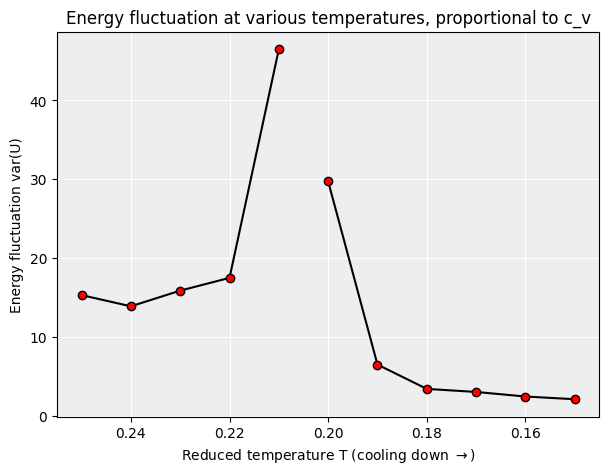

In [58]:
f, a = plt.subplots(figsize=(7,5))
mu = np.mean(np.array([pc.U_samples for pc in res_pcs]), axis=1)
c_v = np.var(np.array([pc.U_samples for pc in res_pcs]), axis=1)

# plt.subplot(1,2,1)
# plt.plot(Ts, mu, marker='o')
# plt.xlabel("T")
# plt.ylabel("<U>")

# plt.subplot(1,2,2)

plt.title("Energy fluctuation at various temperatures, proportional to c_v")
plt.plot(Ts[:5], c_v[:5], "o-", color="black", mfc="r", mec="k")
plt.plot(Ts[5:], c_v[5:], "o-", color="black", mfc="r", mec="k")
plt.xlabel(f"Reduced temperature T (cooling down $\\rightarrow$)")
plt.ylabel("Energy fluctuation var(U)")
plt.grid(c="w")
a.xaxis.set_inverted(True)
a.set_facecolor("#eee")